# Distribución del Dataset de Escarabajos

Este notebook muestra la distribución de imágenes por género, ordenada de mayor a menor.

In [28]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configurar estilo de gráficos
plt.style.use('default')

In [29]:
def analyze_dataset_distribution(data_dir='cropped_beetles/images_no_flash'):
    """
    Analiza y muestra la distribución de imágenes por género, ordenada de mayor a menor.
    
    Args:
        data_dir (str): Ruta al directorio con las imágenes organizadas por género
    """
    
    print("=" * 80)
    print("📊 ANÁLISIS DE DISTRIBUCIÓN DEL DATASET")
    print("=" * 80)
    print(f"📁 Directorio: {data_dir}\n")
    
    # Diccionario para almacenar el conteo por género
    distribution = {}
    
    # Contar imágenes por género
    for genus_folder in sorted(os.listdir(data_dir)):
        genus_path = os.path.join(data_dir, genus_folder)
        
        if os.path.isdir(genus_path):
            # Contar archivos de imagen
            image_count = len([f for f in os.listdir(genus_path) 
                             if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            
            if image_count > 0:
                distribution[genus_folder] = image_count
    
    # Convertir a DataFrame y ordenar de mayor a menor
    df = pd.DataFrame(list(distribution.items()), columns=['Género', 'Número de Imágenes'])
    df = df.sort_values('Número de Imágenes', ascending=False).reset_index(drop=True)
    df['Porcentaje'] = (df['Número de Imágenes'] / df['Número de Imágenes'].sum() * 100).round(2)
    df['Porcentaje Acumulado'] = df['Porcentaje'].cumsum().round(2)
    
    # Mostrar estadísticas generales
    total_images = df['Número de Imágenes'].sum()
    total_classes = len(df)
    
    print(f"✅ Total de géneros: {total_classes}")
    print(f"✅ Total de imágenes: {total_images}")
    print(f"📈 Promedio por género: {df['Número de Imágenes'].mean():.2f}")
    print(f"📊 Mediana: {df['Número de Imágenes'].median():.0f}")
    print(f"📉 Desviación estándar: {df['Número de Imágenes'].std():.2f}")
    print(f"🔝 Máximo: {df['Número de Imágenes'].max()}")
    print(f"🔻 Mínimo: {df['Número de Imágenes'].min()}")
    
    print("\n" + "=" * 80)
    print("📋 DISTRIBUCIÓN COMPLETA (Ordenada de Mayor a Menor)")
    print("=" * 80)
    print(df.to_string(index=False))
    
    return df

# Analizar la distribución
df_distribution = analyze_dataset_distribution('cropped_beetles/images')

📊 ANÁLISIS DE DISTRIBUCIÓN DEL DATASET
📁 Directorio: cropped_beetles/images

✅ Total de géneros: 13
✅ Total de imágenes: 2569
📈 Promedio por género: 197.62
📊 Mediana: 156
📉 Desviación estándar: 189.24
🔝 Máximo: 762
🔻 Mínimo: 50

📋 DISTRIBUCIÓN COMPLETA (Ordenada de Mayor a Menor)
                 Género  Número de Imágenes  Porcentaje  Porcentaje Acumulado
         stenotothorax_                 762       29.66                 29.66
         unknown_beetle                 369       14.36                 44.02
  ontophagus_bidentatus                 237        9.23                 53.25
      canthon_cyanellus                 175        6.81                 60.06
    dichotomius_tristis                 171        6.66                 66.72
      ontophagus_lebasi                 160        6.23                 72.95
       canthon_juvencus                 156        6.07                 79.02
canthon_septemmaculatus                 141        5.49                 84.51
         canthidi

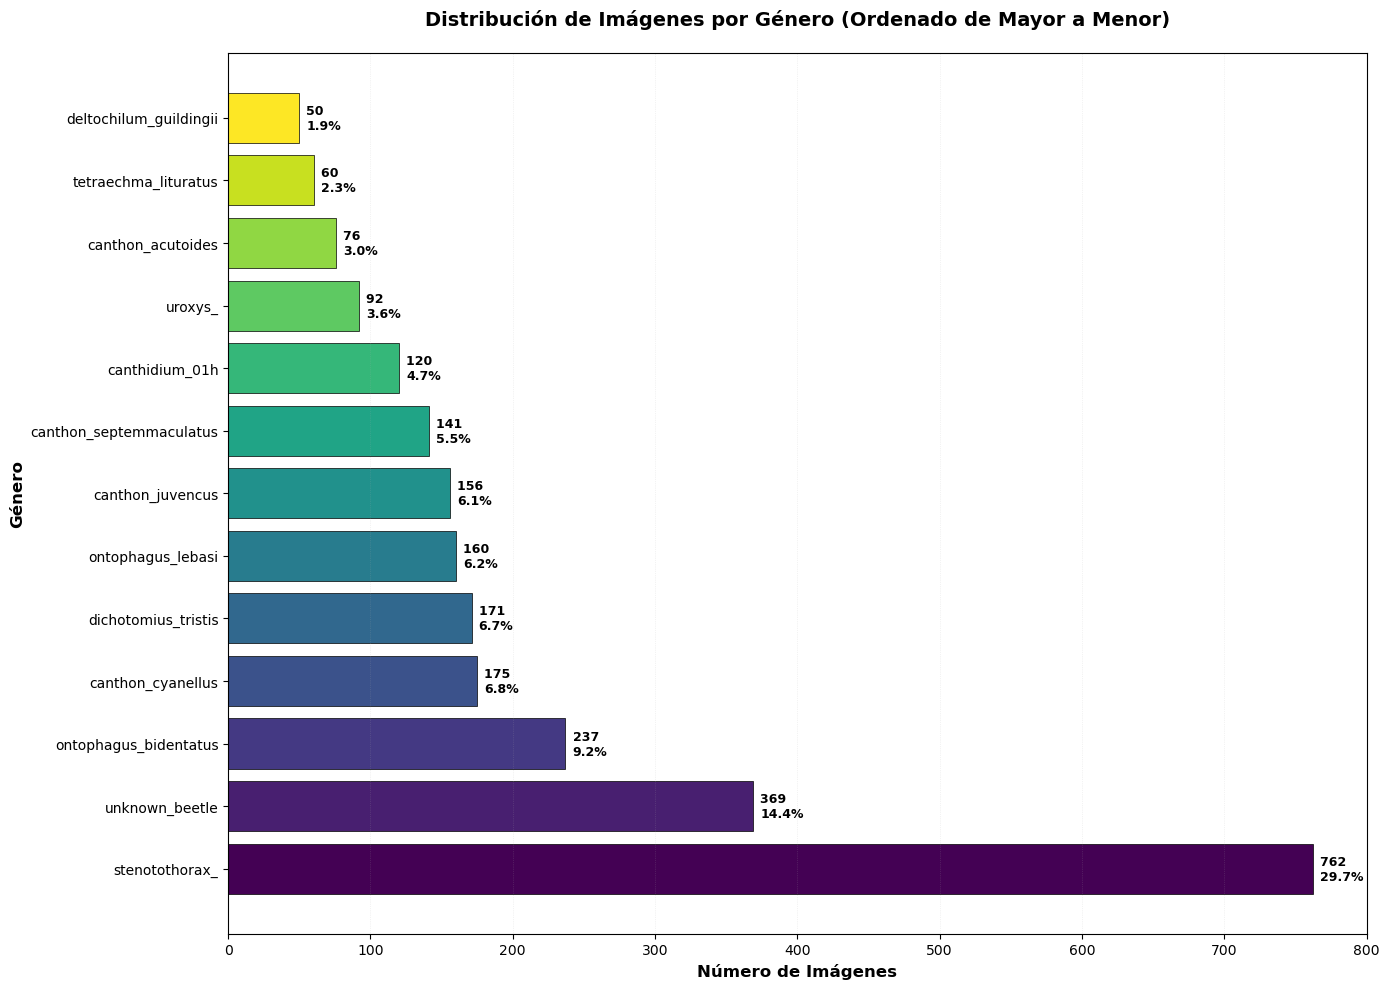

In [30]:
# Gráfico de barras horizontal - Distribución ordenada
plt.figure(figsize=(14, 10))

colors = plt.cm.viridis(np.linspace(0, 1, len(df_distribution)))

bars = plt.barh(df_distribution['Género'], df_distribution['Número de Imágenes'], 
                color=colors, edgecolor='black', linewidth=0.5)

# Añadir valores en las barras
for i, (bar, count, pct) in enumerate(zip(bars, 
                                           df_distribution['Número de Imágenes'], 
                                           df_distribution['Porcentaje'])):
    plt.text(count + 5, i, f'{count} \n{pct:.1f}%', 
            va='center', fontsize=9, fontweight='bold')

plt.xlabel('Número de Imágenes', fontsize=12, fontweight='bold')
plt.ylabel('Género', fontsize=12, fontweight='bold')
plt.title('Distribución de Imágenes por Género (Ordenado de Mayor a Menor)', 
         fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='x', alpha=0.3, linestyle=':', linewidth=0.5)
plt.tight_layout()
plt.show()

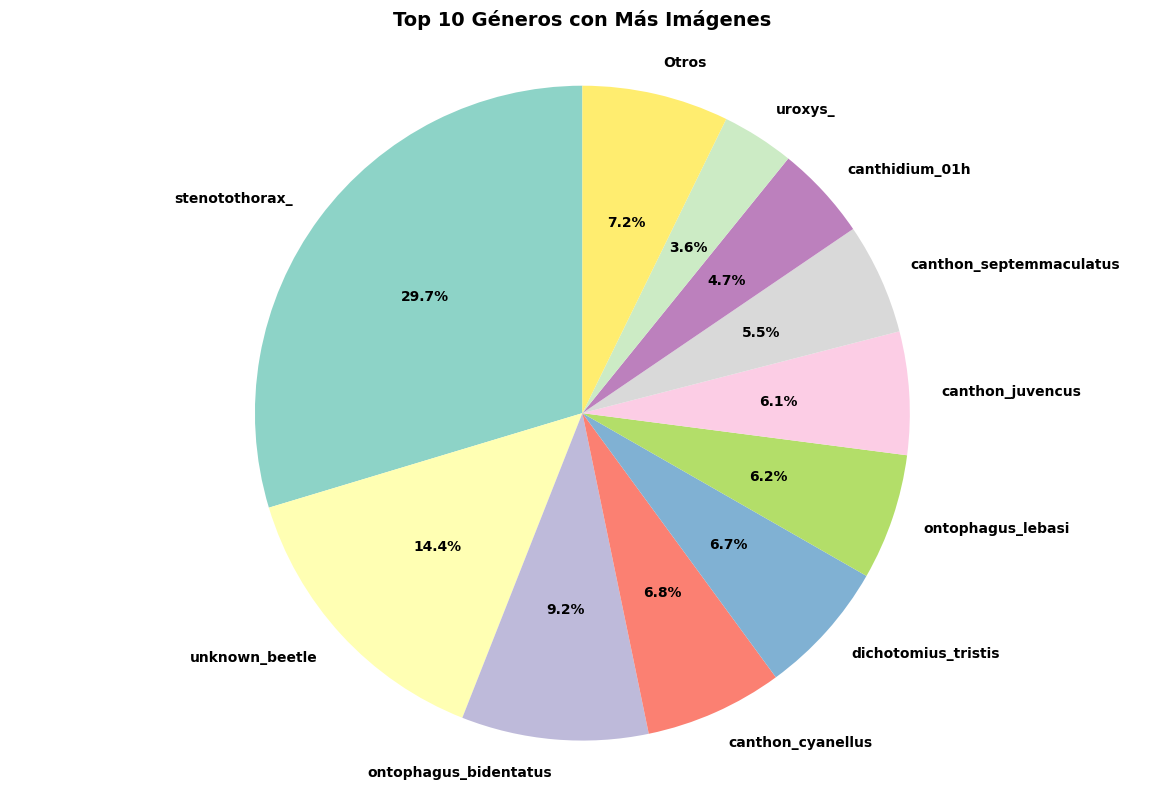

In [31]:
# Gráfico de pastel - Top 10 géneros
plt.figure(figsize=(12, 8))

top_10 = df_distribution.head(10)
otros = df_distribution.iloc[10:]['Número de Imágenes'].sum()

if otros > 0:
    labels = list(top_10['Género']) + ['Otros']
    sizes = list(top_10['Número de Imágenes']) + [otros]
else:
    labels = list(top_10['Género'])
    sizes = list(top_10['Número de Imágenes'])

colors = plt.cm.Set3(np.linspace(0, 1, len(sizes)))

wedges, texts, autotexts = plt.pie(sizes, labels=labels, autopct='%1.1f%%',
                                     colors=colors, startangle=90,
                                     textprops={'fontsize': 10, 'weight': 'bold'})

plt.title('Top 10 Géneros con Más Imágenes', fontsize=14, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

📊 CATEGORIZACIÓN POR TAMAÑO DE DATASET

🟢 Grande (>150 imgs): 7 géneros
   Total de imágenes: 2030
   Géneros: stenotothorax_, unknown_beetle, ontophagus_bidentatus, canthon_cyanellus, dichotomius_tristis, ontophagus_lebasi, canthon_juvencus

🟡 Mediano (50-150 imgs): 6 géneros
   Total de imágenes: 539
   Géneros: canthon_septemmaculatus, canthidium_01h, uroxys_, canthon_acutoides, tetraechma_lituratus, deltochilum_guildingii


C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_5324\1063293532.py:54: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_5324\1063293532.py:54: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Estudiantes\miniconda3\envs\beetles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Estudiantes\miniconda3\envs\beetles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


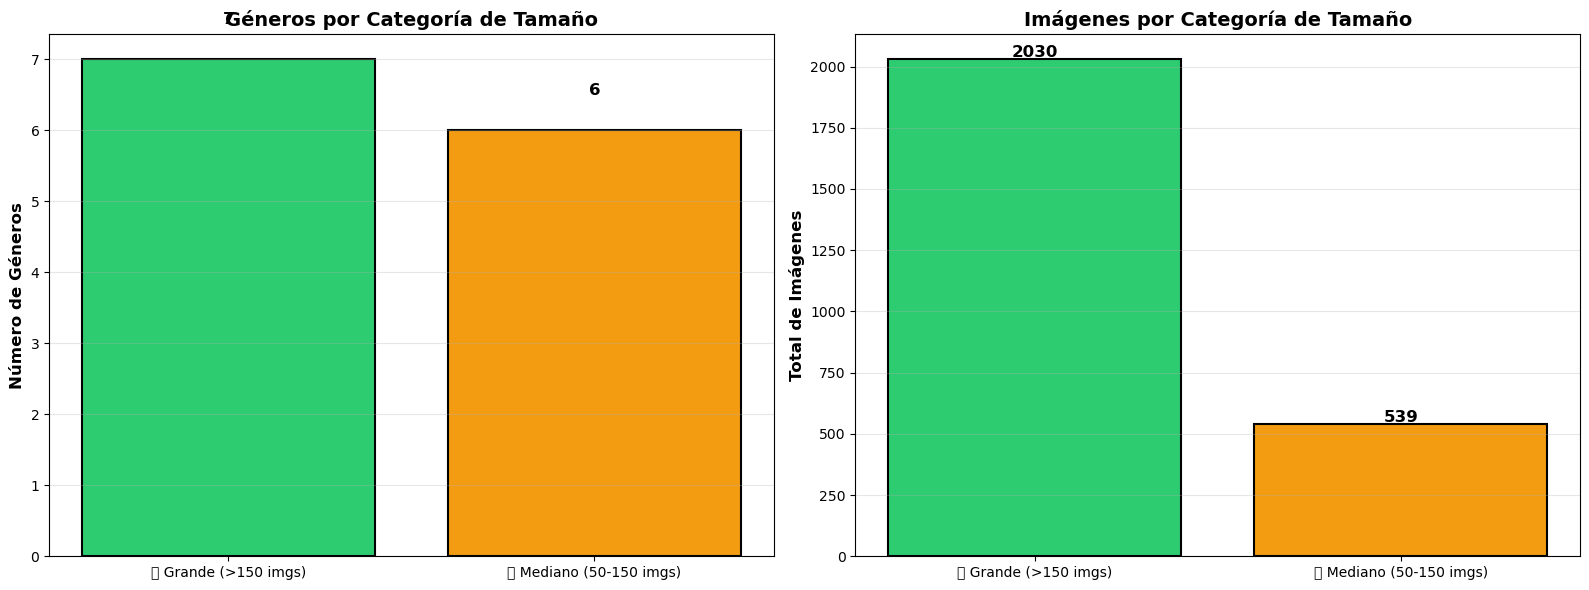

In [32]:
# Análisis de categorías de tamaño de dataset
print("=" * 80)
print("📊 CATEGORIZACIÓN POR TAMAÑO DE DATASET")
print("=" * 80)

# Definir categorías
categorias = {
    '🟢 Grande (>150 imgs)': df_distribution[df_distribution['Número de Imágenes'] > 150],
    '🟡 Mediano (50-150 imgs)': df_distribution[(df_distribution['Número de Imágenes'] >= 50) & 
                                                 (df_distribution['Número de Imágenes'] <= 150)],
    '🟠 Pequeño (10-49 imgs)': df_distribution[(df_distribution['Número de Imágenes'] >= 10) & 
                                               (df_distribution['Número de Imágenes'] < 50)],
    '🔴 Muy Pequeño (<10 imgs)': df_distribution[df_distribution['Número de Imágenes'] < 10]
}

for categoria, datos in categorias.items():
    if len(datos) > 0:
        print(f"\n{categoria}: {len(datos)} géneros")
        print(f"   Total de imágenes: {datos['Número de Imágenes'].sum()}")
        print(f"   Géneros: {', '.join(datos['Género'].tolist())}")

# Gráfico de barras de categorías
cat_names = []
cat_counts = []
cat_images = []

for categoria, datos in categorias.items():
    if len(datos) > 0:
        cat_names.append(categoria)
        cat_counts.append(len(datos))
        cat_images.append(datos['Número de Imágenes'].sum())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Número de géneros por categoría
colors_cat = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
ax1.bar(cat_names, cat_counts, color=colors_cat, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Número de Géneros', fontsize=12, fontweight='bold')
ax1.set_title('Géneros por Categoría de Tamaño', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

for i, v in enumerate(cat_counts):
    ax1.text(i, v + 0.5, str(v), ha='center', fontweight='bold', fontsize=12)

# Gráfico 2: Total de imágenes por categoría
ax2.bar(cat_names, cat_images, color=colors_cat, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Total de Imágenes', fontsize=12, fontweight='bold')
ax2.set_title('Imágenes por Categoría de Tamaño', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

for i, v in enumerate(cat_images):
    ax2.text(i, v + 10, str(v), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)